In [1]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from catboost import CatBoostRegressor, Pool
from merf import MERF

In [2]:
df_research_master = pl.read_csv("data/final_cluster2.csv")

In [107]:
df_research_master["light"].sum()

1698

In [3]:
df_research_master = df_research_master.with_columns(
    pl.when((pl.col("hour").is_between(7, 9)) | (pl.col("hour").is_between(15, 17)))
    .then(1)
    .otherwise(0)
    .alias("is_school_peak")
)

In [4]:
sum_cols = [
    "total_accidents",
    "total_cycling_accidents",
    "car_conflict",
    "severity",
    "slick",
    "light",
    "intersection",
    "school_peak",
    "local_accidents",
]

mean_cols = [
    "total_hourly_flow",
    "avg_temp",
    "avg_precip",
    "avg_mun_wind",
    "bad_weather_ratio",
    "relative_sensor_age",
    "avg_income_per_capita",
    "prof_earner_ratio",
    "avg_employment_rate",
    "inbound_push_ratio",
]

temporal_cols = ["is_weekend"]
demo_cols = [
    col
    for col in df_research_master.columns
    if col.startswith("pct_") or col == "total_pop"
]

In [5]:
df_yearly = df_research_master.group_by(["gemeente", "year"]).agg(
    [pl.col(c).mean().alias(f"{c}_ratio") for c in temporal_cols]
    + [
        pl.col("total_accidents").filter(pl.col(c) == 1).sum().alias(f"acc_during_{c}")
        for c in temporal_cols
    ]
    + [pl.col(c).sum() for c in sum_cols]
    + [pl.col(c).mean() for c in mean_cols]
    + [pl.col(c).mean() for c in demo_cols]
)

In [6]:
df_yearly = df_yearly.with_columns(
    [
        (pl.col("total_accidents") / pl.col("total_hourly_flow")).alias(
            "accident_rate_per_flow"
        ),
        (pl.col("total_accidents") / pl.col("total_pop")).alias(
            "accident_rate_per_capita"
        ),
        (pl.col("severity") / pl.col("total_accidents")).alias("severity_index"),
    ]
)

In [7]:
df_yearly.head()

gemeente,year,is_weekend_ratio,acc_during_is_weekend,total_accidents,total_cycling_accidents,car_conflict,severity,slick,light,intersection,school_peak,local_accidents,total_hourly_flow,avg_temp,avg_precip,avg_mun_wind,bad_weather_ratio,relative_sensor_age,avg_income_per_capita,prof_earner_ratio,avg_employment_rate,inbound_push_ratio,total_pop,pct_young_children,pct_school_kids,pct_uni_students,pct_young_profs,pct_senior_profs,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced,accident_rate_per_flow,accident_rate_per_capita,severity_index
str,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Heers""",2024,0.25,3,11,2,2,0,0,0,0,0,0,172.038194,10.610829,0.121681,13.680491,0.182086,2.0,24738.925847,0.601064,0.730329,0.501041,7593.0,0.07204,0.106677,0.074411,0.171342,0.35243,0.2231,0.498749,0.501251,0.952588,0.047412,0.445674,0.405373,0.059002,0.089951,0.063939,0.001449,0.0
"""Wemmel""",2022,0.261905,11,36,4,2,2,1,0,0,3,0,204.994048,14.393533,0.078423,11.609041,0.127047,0.0,23524.288578,0.54444,0.695224,0.87197,17182.0,0.096904,0.128565,0.094343,0.172332,0.31469,0.193167,0.485857,0.514143,0.829356,0.170644,0.498138,0.363404,0.05238,0.086078,0.175615,0.002095,0.055556
"""Sint-Pieters-Leeuw""",2023,0.333333,17,66,5,5,0,0,1,3,1,0,62.211806,11.981935,0.110064,14.335422,0.173258,1.0,22460.88566,0.551814,0.695788,0.690701,36052.0,0.095723,0.131283,0.099135,0.167037,0.325918,0.180905,0.489293,0.510707,0.828886,0.171114,0.501886,0.375763,0.050455,0.071896,1.060892,0.001831,0.0
"""Peer""",2023,0.333333,10,38,10,5,0,3,2,6,6,0,443.364583,10.856514,0.125038,14.775066,0.212889,1.0,23298.094114,0.576545,0.716611,0.73964,16534.0,0.075239,0.11177,0.080259,0.160578,0.358957,0.213197,0.501633,0.498367,0.926455,0.073545,0.443389,0.425366,0.05026,0.080985,0.085708,0.002298,0.0
"""Heers""",2022,0.2,1,7,3,2,1,1,1,1,0,0,170.454167,12.47443,0.080154,12.243227,0.127756,0.0,22098.014063,0.59068,0.707149,0.510268,7457.0,0.075634,0.103259,0.077779,0.17098,0.361405,0.210943,0.500201,0.499799,0.954137,0.045863,0.438514,0.41156,0.057664,0.092262,0.041067,0.000939,0.142857


In [8]:
# previous year features
df_features = df_yearly.sort(["gemeente", "year"]).with_columns(
    [
        pl.col("severity")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_severe_count"),
        pl.col("light")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_dark_count"),
        pl.col("acc_during_is_weekend")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_weekend_count"),
        pl.col("local_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_local_accidents"),
        pl.col("school_peak")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_school_accidents"),
        pl.col("slick")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_slick_accidents"),
        pl.col("car_conflict")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_carconflict_accidents"),
        pl.col("intersection")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_int_accidents"),
        pl.col("total_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_total_accidents"),
        pl.col("total_cycling_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_total_cyc_accidents"),
        pl.col("total_cycling_accidents")
        .mean()
        .over("gemeente")
        .alias("historical_town_avg"),
    ]
)

In [9]:
df_features = df_features.with_columns(
    [
        (
            pl.col("pct_school_kids")
            * pl.col("total_pop")
            / pl.col("total_hourly_flow")
        ).alias("school_zone_exposure"),
        (pl.col("prev_year_total_accidents") / (pl.col("total_pop") / 1000)).alias(
            "risk_per_1k_residents"
        ),
        (pl.col("avg_mun_wind") * pl.col("avg_precip")).alias("weather_severity_index"),
        (pl.col("total_hourly_flow") / pl.col("total_pop")).alias("flow_density"),
    ]
)

In [10]:
df_features = df_features.sort(["gemeente", "year"]).with_columns(
    pl.col("total_cycling_accidents")
    .backward_fill()
    .over("gemeente")
    .alias("smoothed_target")
)

In [11]:
upper_limit = df_features["total_hourly_flow"].quantile(0.99)
df_features = df_features.with_columns(
    pl.col("total_hourly_flow").clip(upper_bound=upper_limit)
)

In [12]:
features = [
    "total_hourly_flow",
    "avg_temp",
    "avg_precip",
    "avg_mun_wind",
    "avg_income_per_capita",
    "prof_earner_ratio",
    "avg_employment_rate",
    "total_pop",
    "pct_young_children",
    "pct_school_kids",
    "pct_uni_students",
    "pct_young_profs",
    "pct_senior_profs",
    "pct_seniors",
    "pct_male",
    "pct_belgian",
    "pct_single",
    "pct_married",
    "pct_widowed",
    "prev_year_severe_count",
    "prev_year_dark_count",
    "prev_year_weekend_count",
    "prev_year_total_accidents",
    "prev_year_school_accidents",
    "prev_year_slick_accidents",
    "prev_year_local_accidents",
    "prev_year_total_cyc_accidents",
    "historical_town_avg",
    "prev_year_carconflict_accidents",
    "prev_year_int_accidents",
    "school_zone_exposure",
    "risk_per_1k_residents",
    "flow_density",
    "bad_weather_ratio",
    "relative_sensor_age",
    "inbound_push_ratio",
]

In [13]:
df_features = (
    df_features.with_columns(
        [
            pl.when(pl.col(col).is_infinite())
            .then(0.0)
            .otherwise(pl.col(col))
            .alias(col)
            for col in features
        ]
    )
    .fill_null(0.0)
    .with_columns([pl.col(col).cast(pl.Float32) for col in features])
)

In [14]:
train_df = df_features.filter(pl.col("year").is_in([2021, 2022, 2023]))
val_df = df_features.filter(pl.col("year") == 2024)
test_df = df_features.filter(pl.col("year") == 2025)

In [15]:
X_train = train_df.select(features).to_pandas()
y_train = train_df.select("smoothed_target").to_pandas().values.flatten()

In [16]:
y_train

array([ 19.,  41.,  22.,  33.,   7.,  10.,  10.,   4.,  14.,  26.,  15.,
        15.,  18.,   5.,  14.,  19.,  17.,  22.,  50.,  55.,  79.,  19.,
        29.,  31.,  35.,  30., 180., 227., 212.,  20.,  42.,  26.,  81.,
        10.,  16.,  31.,  48.,  45.,  55.,  35.,  46.,  78., 131.,  82.,
       494., 632., 538.,  96.,   3.,   2.,  29.,  45.,  35.,  14.,  24.,
        25.,  47.,   7.,  12.,  35.,  74.,  74.,  29.,  41.,   7.,  13.,
       106., 143., 122.,   5.,   1.,   1.,  15.,  11., 141., 211.,  28.,
        67.,  13.,  20.,  74.,  39.,  36.,   3.,  11.,  18.,  18.,  20.,
        28.,  10.,  21.,  74., 118.,  10.,  14.,   8.,   9.,  12.,   5.,
         5.,   3.,  20.,  15.,  17.,  22.,  25.,  84.,  83.,  80.,  11.,
        10.,  37.,  55.,   1.,   2.,   2.,   5.,  23.,  27.,  29.,  22.,
        25.,  10.,  21.,  48.,  48.,   4.,  11.,  13.,  28.,  20.,  30.,
         6.,  20.,  12.,  11.,  41.,  10.,  21.])

In [17]:
X_val = val_df.select(features).to_pandas()
y_val = val_df.select("smoothed_target").to_pandas().values.flatten()

In [18]:
y_val

array([105.,  37.,  41.,   7.,   7.,  35.,  18.,   9.,  58.,  16.,  72.,
        21.,  37., 203.,  36.,  70.,   6.,  30.,  53.,  52.,  93., 550.,
        30.,  37.,  89.,   2.,  44.,  14.,  45.,   7.,  36.,  56.,  30.,
        10., 122.,   3.,   5., 208.,  53.,  13., 104.,  32.,   9.,  18.,
        21.,  12., 125.,  18.,  22.,  13.,   9.,  15.,  15.,  91.,  13.,
        25.,   5.,  12.,  19.,  26.,  17.,  36.,   4.,  17.,  31.,  18.,
        39.,  17.])

In [19]:
X_test = test_df.select(features).to_pandas()

In [20]:
pop_weights = (train_df["total_pop"] / train_df["total_pop"].mean()).to_numpy()

In [21]:
X_train_scaled = StandardScaler().fit_transform(X_train)
X_val_scaled = StandardScaler().fit_transform(X_val)
X_test_scaled = StandardScaler().fit_transform(X_test)

In [22]:
def plot_lorenz_curve(y_true, y_pred, label, fig=None, ax=None):
    if fig is None:
        fig = plt.gcf()
    if ax is None:
        ax = plt.gca()

    y_true_flat = np.array(y_true).flatten()
    y_pred_flat = np.array(y_pred).flatten()

    df_eval = pd.DataFrame({"true": y_true_flat, "pred": y_pred_flat}).sort_values(
        "pred"
    )

    cum_true = np.cumsum(df_eval["true"]) / np.sum(df_eval["true"])
    cum_pop = np.arange(1, len(cum_true) + 1) / len(cum_true)

    area_under_curve = np.trapezoid(cum_true, cum_pop)
    gini = 1 - 2 * area_under_curve

    ax.plot(cum_pop, cum_true, label=f"{label} (Gini: {gini:.3f})")
    return gini

In [23]:
print(
    f"Train: {X_train.shape}  ({train_df['gemeente'].n_unique()} municipalities, 2021 - 2023)\n"
)
print(f"Val: {X_val.shape}   ({val_df['gemeente'].n_unique()} municipalities, 2024)\n")
print(
    f"Test: {X_test.shape}  ({test_df['gemeente'].n_unique()} municipalities, 2025)\n"
)
print(f"Features: {len(features)}")

Train: (139, 36)  (64 municipalities, 2021 - 2023)

Val: (68, 36)   (68 municipalities, 2024)

Test: (62, 36)  (62 municipalities, 2025)

Features: 36


# Model 1
## Two Stage Model

for this model, I'm dividing them into two distinct categories. low risk ones, and high risk ones. threshold is set at the median

In [24]:
median_threshold = np.median(y_train)
print(f"Median threshold for low/high split: {median_threshold:.2f}")

Median threshold for low/high split: 22.00


In [25]:
y_train_tier = (y_train > median_threshold).astype(int)  # 0 = low, 1 = high
y_val_tier = (y_val > median_threshold).astype(int)

In [26]:
print(
    f"Train — Low risk: {(y_train_tier==0).sum()}, High risk: {(y_train_tier==1).sum()}"
)
print(
    f"Val   — Low risk: {(y_val_tier==0).sum()},   High risk: {(y_val_tier==1).sum()}"
)

Train — Low risk: 71, High risk: 68
Val   — Low risk: 33,   High risk: 35


In [27]:
scaler_two_stage = StandardScaler()
X_train_1 = scaler_two_stage.fit_transform(X_train)
X_val_1 = scaler_two_stage.transform(X_val)
X_test_1 = scaler_two_stage.transform(X_test)

In [28]:
stage1_model = LogisticRegression(max_iter=1000, C=0.5, random_state=7)
stage1_model.fit(X_train_1, y_train_tier, sample_weight=pop_weights)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",7
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

with `stage1_model` I'm trying to define whether it's gonna be low or high risk

In [29]:
p_high_val = stage1_model.predict_proba(X_val_1)[:, 1]
p_high_test = stage1_model.predict_proba(X_test_1)[:, 1]

In [30]:
low_mask = y_train_tier == 0
high_mask = y_train_tier == 1

In [31]:
model_low = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42,
)

In [32]:
model_low.fit(
    X_train[low_mask],
    y_train[low_mask],
    sample_weight=pop_weights[low_mask],
    verbose=False,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [33]:
model_high = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=7,
    random_state=42,
)

In [34]:
model_high.fit(
    X_train[high_mask],
    y_train[high_mask],
    sample_weight=pop_weights[high_mask],
    verbose=False,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [35]:
val_preds_1 = p_high_val * model_high.predict(X_val) + (
    1 - p_high_val
) * model_low.predict(X_val)

In [36]:
test_preds_1 = p_high_test * model_high.predict(X_test) + (
    1 - p_high_test
) * model_low.predict(X_test)

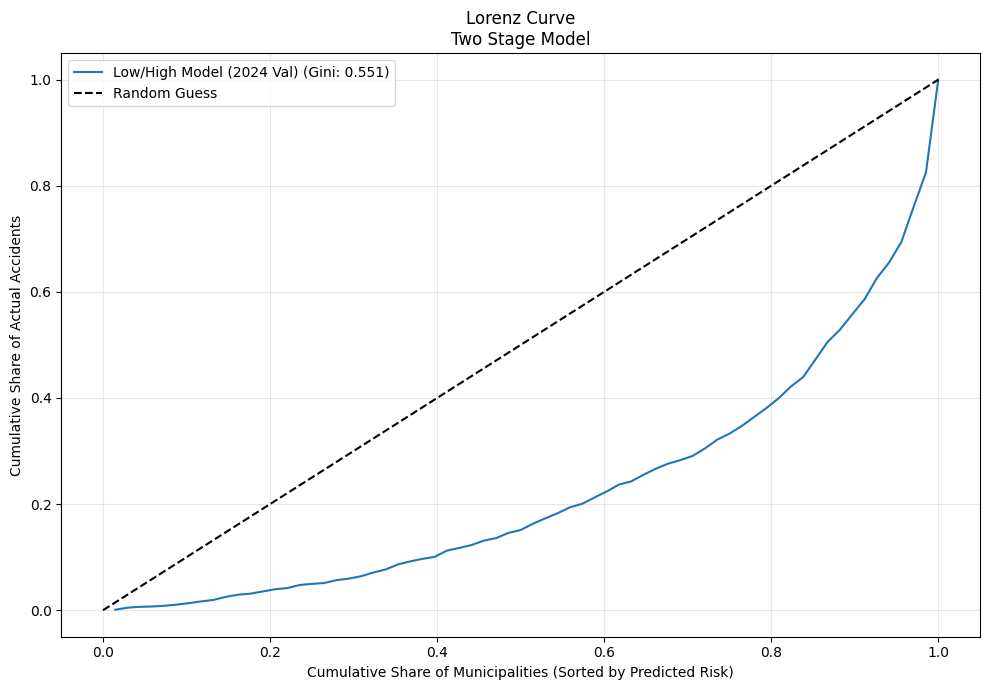

In [37]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_lorenz_curve(y_val, val_preds_1, "Low/High Model (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")
ax.set_title("Lorenz Curve\nTwo Stage Model")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

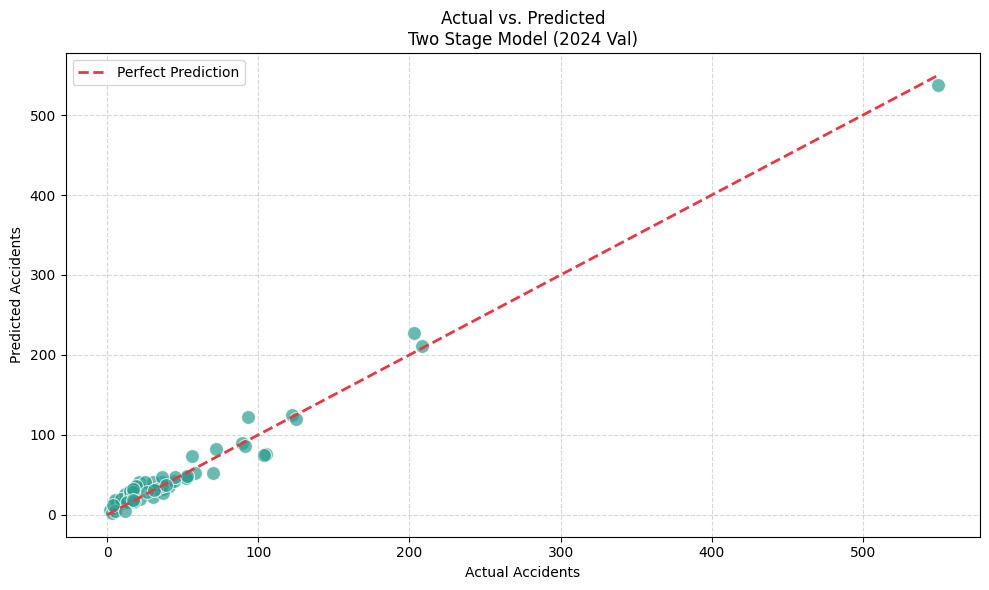

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(x=y_val, y=val_preds_1, alpha=0.7, color="#2A9D8F", s=100, ax=ax)

max_val = max(y_val.max(), val_preds_1.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)

ax.set_title("Actual vs. Predicted\nTwo Stage Model (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)


fig.tight_layout()

In [39]:
split_model_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_split_model", values=test_preds_1)
)

In [40]:
print("\nTop 10 High-Risk Municipalities — Two Stage Model (2025):")
print(split_model_results_2025.sort("pred_split_model", descending=True).head(10))


Top 10 High-Risk Municipalities — Two Stage Model (2025):
shape: (10, 3)
┌──────────┬────────┬──────────────────┐
│ gemeente ┆ year   ┆ pred_split_model │
│ ---      ┆ ---    ┆ ---              │
│ str      ┆ f64    ┆ f64              │
╞══════════╪════════╪══════════════════╡
│ Gent     ┆ 2025.0 ┆ 624.899658       │
│ Brugge   ┆ 2025.0 ┆ 226.971015       │
│ Leuven   ┆ 2025.0 ┆ 203.573807       │
│ Kortrijk ┆ 2025.0 ┆ 141.217908       │
│ Mechelen ┆ 2025.0 ┆ 124.582683       │
│ Aalst    ┆ 2025.0 ┆ 109.61362        │
│ Lokeren  ┆ 2025.0 ┆ 94.267404        │
│ Hasselt  ┆ 2025.0 ┆ 92.808789        │
│ Genk     ┆ 2025.0 ┆ 91.846058        │
│ Oostende ┆ 2025.0 ┆ 86.789366        │
└──────────┴────────┴──────────────────┘


# Model 
## Catboost

In [41]:
train_pool = Pool(X_train, label=y_train, weight=pop_weights)
val_pool = Pool(X_val, label=y_val)
test_pool = Pool(X_test)

In [42]:
model_cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.02,
    depth=8,
    loss_function="Tweedie:variance_power=1.5",
    eval_metric="RMSE",
    random_seed=15,
    early_stopping_rounds=50,
    verbose=100,
)

In [43]:
model_cat.fit(train_pool, eval_set=val_pool)

0:	learn: 229.6164538	test: 87.2309073	best: 87.2309073 (0)	total: 58.6ms	remaining: 58.5s
100:	learn: 227.5188862	test: 85.8648216	best: 85.8648216 (100)	total: 169ms	remaining: 1.51s
200:	learn: 226.5344153	test: 85.3677360	best: 85.3677360 (200)	total: 285ms	remaining: 1.13s
300:	learn: 226.3504836	test: 85.2915471	best: 85.2915471 (300)	total: 444ms	remaining: 1.03s
400:	learn: 226.3220324	test: 85.2823714	best: 85.2823714 (400)	total: 564ms	remaining: 842ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 85.28185503
bestIteration = 449

Shrink model to first 450 iterations.


CatBoostRegressor(depth=8, early_stopping_rounds=50, eval_metric='RMSE', iterations=1000, learning_rate=0.02, loss_function='Tweedie:variance_power=1.5', random_seed=15, verbose=100)

In [44]:
feat_importance = pd.Series(
    model_cat.get_feature_importance(), index=features
).sort_values(
    ascending=False
)  # type: ignore

In [45]:
feat_importance

historical_town_avg                12.512664
total_pop                           7.165029
total_hourly_flow                   5.345803
pct_uni_students                    4.477025
flow_density                        4.345279
pct_senior_profs                    4.132505
pct_married                         3.815063
pct_young_profs                     3.507188
pct_male                            3.447250
pct_widowed                         3.015337
inbound_push_ratio                  2.941305
pct_seniors                         2.884722
avg_temp                            2.840592
pct_belgian                         2.653090
avg_income_per_capita               2.649866
pct_school_kids                     2.599490
bad_weather_ratio                   2.547252
avg_employment_rate                 2.532504
school_zone_exposure                2.351371
pct_single                          2.314240
prof_earner_ratio                   2.262961
relative_sensor_age                 2.115115
avg_mun_wi

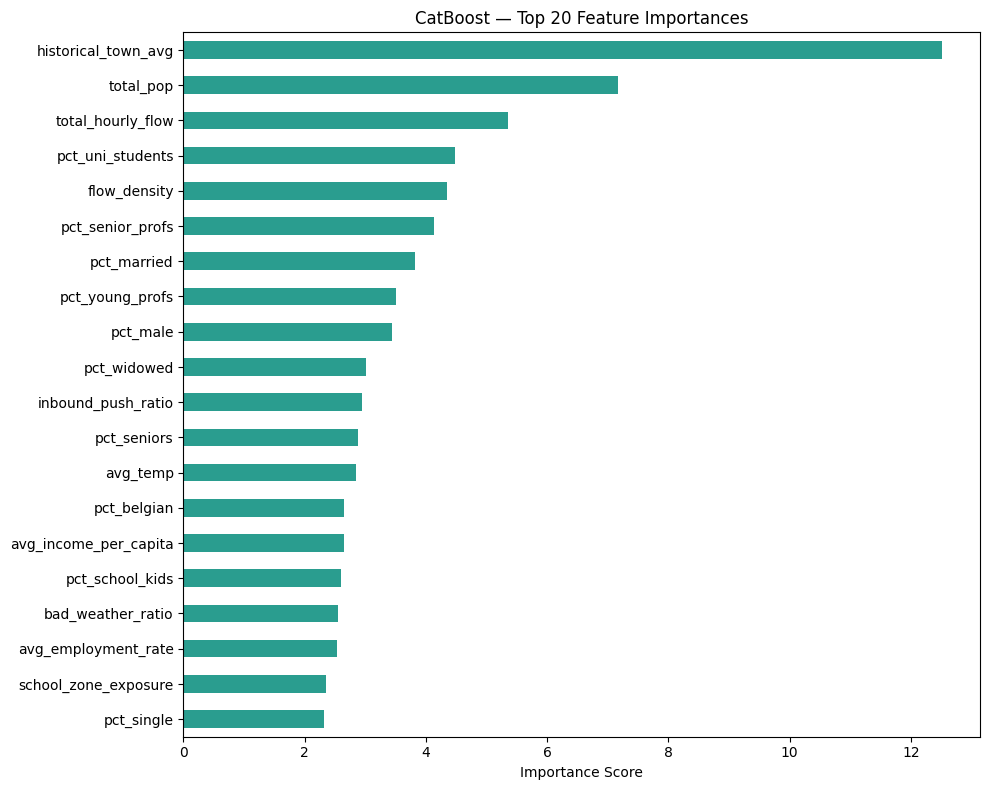

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))

feat_importance.head(20).plot(kind="barh", color="#2A9D8F", ax=ax)
ax.invert_yaxis()

ax.set_title("CatBoost — Top 20 Feature Importances")
ax.set_xlabel("Importance Score")

fig.tight_layout()

In [47]:
val_preds_cat = model_cat.predict(val_pool)

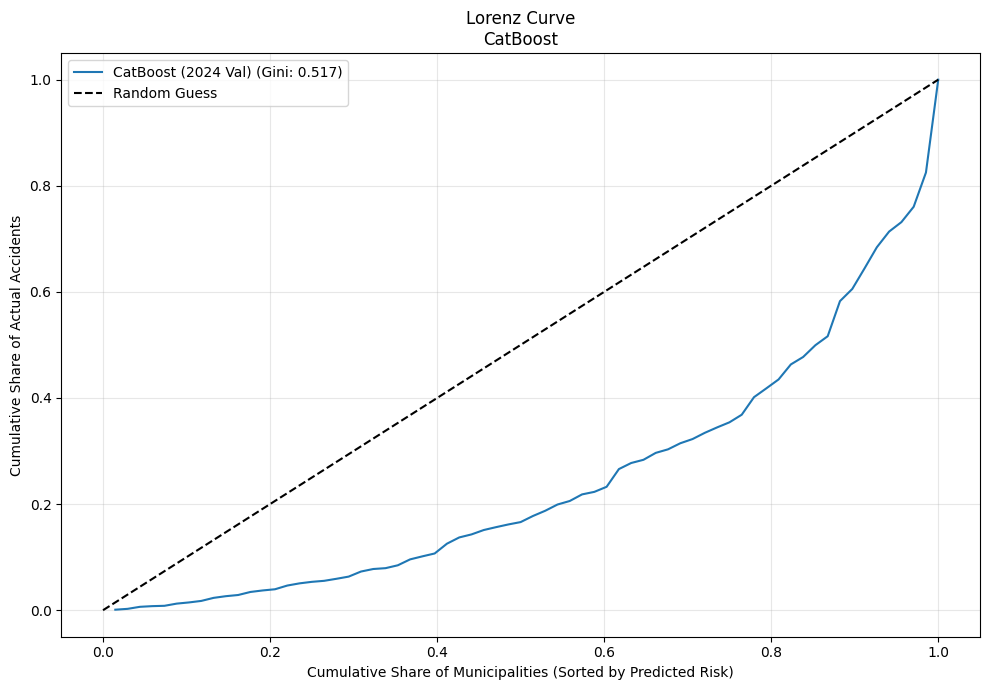

In [48]:
fig, ax = plt.subplots(figsize=(10, 7))

plot_lorenz_curve(y_val, val_preds_cat, "CatBoost (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")

ax.set_title("Lorenz Curve\nCatBoost")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

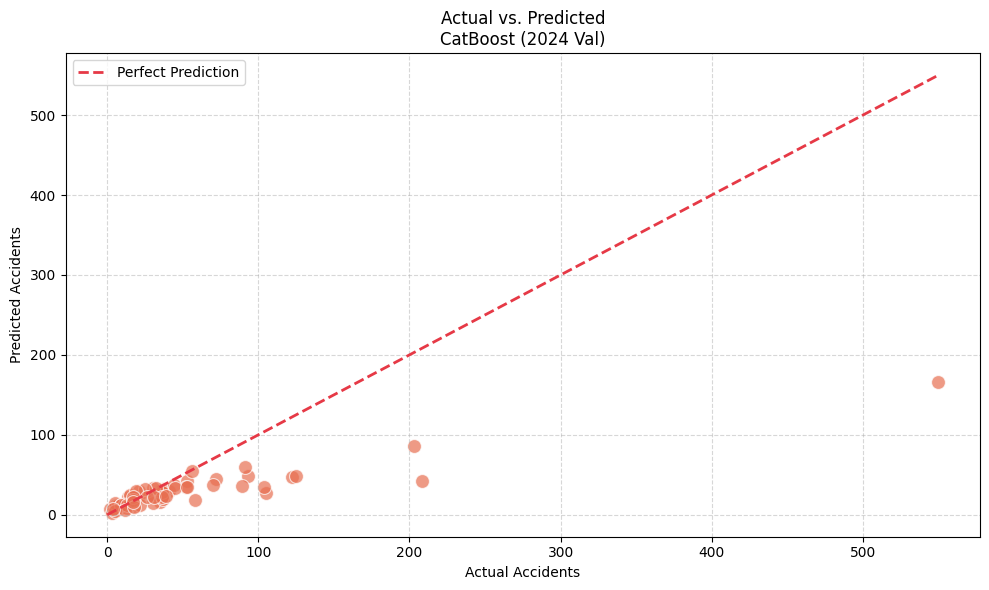

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(x=y_val, y=val_preds_cat, alpha=0.7, color="#E76F51", s=100, ax=ax)

max_val = max(y_val.max(), val_preds_cat.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)

ax.set_title("Actual vs. Predicted\nCatBoost (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()

In [50]:
test_preds_cat = model_cat.predict(test_pool)

In [51]:
cat_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_catboost", values=test_preds_cat)
)

In [52]:
print("\nTop 10 High-Risk Municipalities — CatBoost (2025):")
print(cat_results_2025.sort("pred_catboost", descending=True).head(10))


Top 10 High-Risk Municipalities — CatBoost (2025):
shape: (10, 3)
┌──────────┬────────┬───────────────┐
│ gemeente ┆ year   ┆ pred_catboost │
│ ---      ┆ ---    ┆ ---           │
│ str      ┆ f64    ┆ f64           │
╞══════════╪════════╪═══════════════╡
│ Ieper    ┆ 2025.0 ┆ 48.866735     │
│ Brugge   ┆ 2025.0 ┆ 47.797785     │
│ Gent     ┆ 2025.0 ┆ 42.435792     │
│ Oostende ┆ 2025.0 ┆ 37.756661     │
│ Izegem   ┆ 2025.0 ┆ 30.028081     │
│ Evergem  ┆ 2025.0 ┆ 28.995499     │
│ Hasselt  ┆ 2025.0 ┆ 25.128707     │
│ Kortrijk ┆ 2025.0 ┆ 24.641764     │
│ Diest    ┆ 2025.0 ┆ 23.691099     │
│ Aarschot ┆ 2025.0 ┆ 23.530328     │
└──────────┴────────┴───────────────┘


# Model 3
## XGBoost

In [53]:
dtrain_xgb = xgb.DMatrix(X_train, label=y_train, weight=pop_weights)
dval_xgb = xgb.DMatrix(X_val, label=y_val)
dtest_xgb = xgb.DMatrix(X_test)

In [54]:
xgb_params = {
    "objective": "count:poisson",
    "eval_metric": "mae",
    "learning_rate": 0.02,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "gamma": 0.1,
    "seed": 25,
}

In [55]:
model_xgb = xgb.train(
    xgb_params,
    dtrain_xgb,
    num_boost_round=1000,
    evals=[(dtrain_xgb, "train"), (dval_xgb, "val")],
    early_stopping_rounds=50,
    verbose_eval=100,
)

[0]	train-mae:135.74640	val-mae:105.35985
[100]	train-mae:54.69884	val-mae:41.73813
[200]	train-mae:20.53108	val-mae:18.14189
[300]	train-mae:8.07850	val-mae:10.07221
[400]	train-mae:3.42205	val-mae:8.01472
[500]	train-mae:1.69496	val-mae:7.41020
[600]	train-mae:1.12848	val-mae:7.19253
[662]	train-mae:0.97675	val-mae:7.20063


In [56]:
feat_imp_xgb = pd.Series(
    model_xgb.get_score(importance_type="gain"), name="gain"
).sort_values(ascending=False)

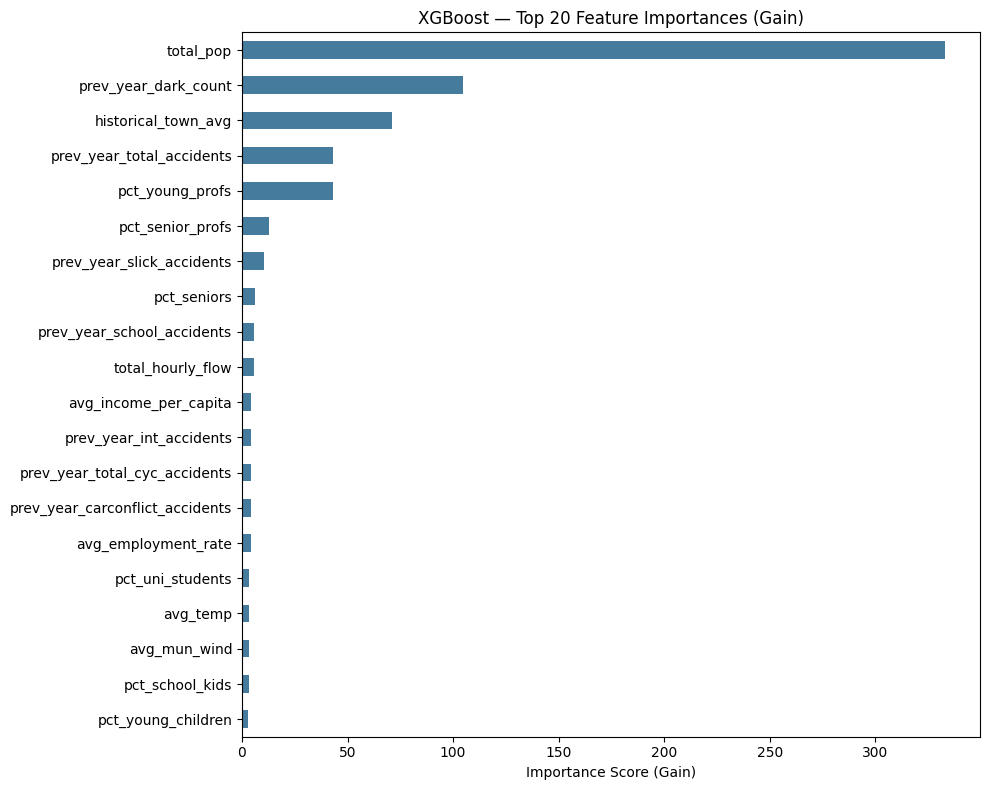

In [57]:
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp_xgb.head(20).plot(kind="barh", color="#457B9D", ax=ax)
ax.invert_yaxis()
ax.set_title("XGBoost — Top 20 Feature Importances (Gain)")
ax.set_xlabel("Importance Score (Gain)")
fig.tight_layout()

In [58]:
val_preds_xgb = model_xgb.predict(dval_xgb)

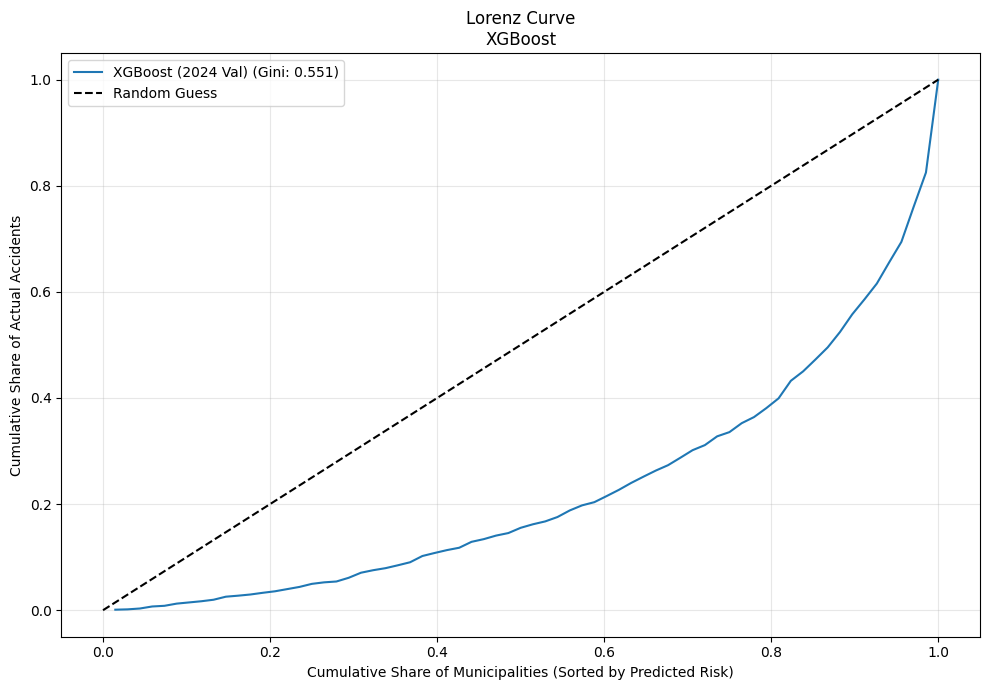

In [59]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_lorenz_curve(y_val, val_preds_xgb, "XGBoost (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")
ax.set_title("Lorenz Curve\nXGBoost")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

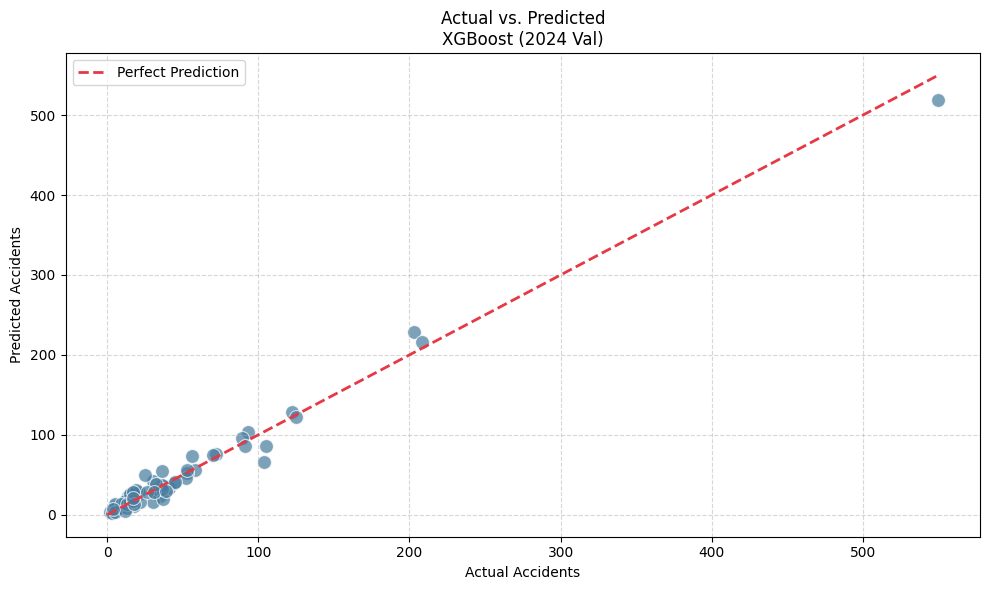

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=y_val, y=val_preds_xgb, alpha=0.7, color="#457B9D", s=100, ax=ax)
max_val = max(y_val.max(), val_preds_xgb.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)
ax.set_title("Actual vs. Predicted\nXGBoost (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()

In [61]:
test_preds_xgb = model_xgb.predict(dtest_xgb)
xgb_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_xgb", values=test_preds_xgb)
)

In [62]:
print("\nTop 10 High-Risk Municipalities — XGBoost (2025):")
print(xgb_results_2025.sort("pred_xgb", descending=True).head(10))


Top 10 High-Risk Municipalities — XGBoost (2025):
shape: (10, 3)
┌──────────┬────────┬────────────┐
│ gemeente ┆ year   ┆ pred_xgb   │
│ ---      ┆ ---    ┆ ---        │
│ str      ┆ f64    ┆ f32        │
╞══════════╪════════╪════════════╡
│ Gent     ┆ 2025.0 ┆ 463.481873 │
│ Brugge   ┆ 2025.0 ┆ 238.026855 │
│ Leuven   ┆ 2025.0 ┆ 209.470032 │
│ Kortrijk ┆ 2025.0 ┆ 136.440659 │
│ Mechelen ┆ 2025.0 ┆ 128.291901 │
│ Aalst    ┆ 2025.0 ┆ 110.951653 │
│ Hasselt  ┆ 2025.0 ┆ 97.477013  │
│ Genk     ┆ 2025.0 ┆ 89.606773  │
│ Oostende ┆ 2025.0 ┆ 89.523407  │
│ Lokeren  ┆ 2025.0 ┆ 76.099174  │
└──────────┴────────┴────────────┘


# Model 4
## MERF

In [63]:
X_train_merf = train_df.select(features).to_pandas()
y_train_merf = train_df.select("smoothed_target").to_pandas().values.flatten()
clusters_train = train_df["gemeente"].to_pandas()
Z_train = np.ones((len(X_train_merf), 1))

In [64]:
X_val_merf = val_df.select(features).to_pandas()
y_val_merf = val_df.select("smoothed_target").to_pandas().values.flatten()
clusters_val = val_df["gemeente"].to_pandas()
Z_val = np.ones((len(X_val_merf), 1))

In [65]:
X_test_merf = test_df.select(features).to_pandas()
clusters_test = test_df["gemeente"].to_pandas()
Z_test = np.ones((len(X_test_merf), 1))

In [66]:
model_merf = MERF(max_iterations=30)
model_merf.fit(X_train_merf, Z_train, clusters_train, y_train_merf)

INFO     [merf.py:307] Training GLL is 983.9589276751179 at iteration 1.
INFO     [merf.py:307] Training GLL is 1066.5130625655192 at iteration 2.
INFO     [merf.py:307] Training GLL is 1083.4655220969591 at iteration 3.
INFO     [merf.py:307] Training GLL is 1118.3315755909155 at iteration 4.
INFO     [merf.py:307] Training GLL is 1115.0600876870212 at iteration 5.
INFO     [merf.py:307] Training GLL is 1115.7885019671119 at iteration 6.
INFO     [merf.py:307] Training GLL is 1116.0361379089672 at iteration 7.
INFO     [merf.py:307] Training GLL is 1146.3242288186048 at iteration 8.
INFO     [merf.py:307] Training GLL is 1146.4836254761574 at iteration 9.
INFO     [merf.py:307] Training GLL is 1161.212334196755 at iteration 10.
INFO     [merf.py:307] Training GLL is 1173.5191452910917 at iteration 11.
INFO     [merf.py:307] Training GLL is 1167.1006759759935 at iteration 12.
INFO     [merf.py:307] Training GLL is 1173.0079089918993 at iteration 13.
INFO     [merf.py:307] Training GLL 

In [67]:
val_preds_merf = model_merf.predict(X_val_merf, Z_val, clusters_val)

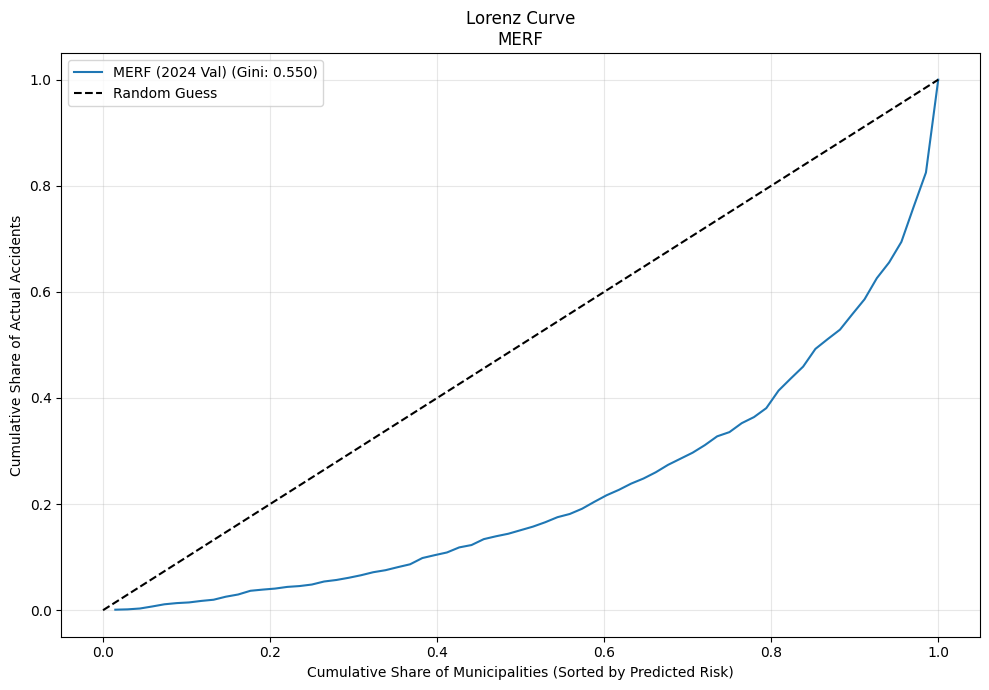

In [68]:
fig, ax = plt.subplots(figsize=(10, 7))

plot_lorenz_curve(y_val_merf, val_preds_merf, "MERF (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")

ax.set_title("Lorenz Curve\nMERF")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

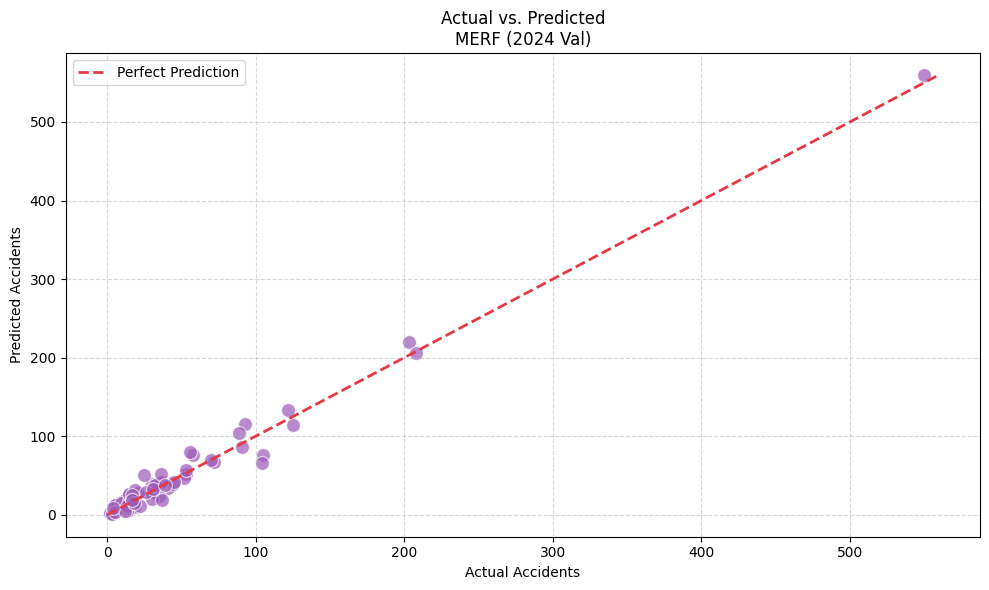

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    x=y_val_merf, y=val_preds_merf, alpha=0.7, color="#9b59b6", s=100, ax=ax
)

max_val = max(y_val_merf.max(), val_preds_merf.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)

ax.set_title("Actual vs. Predicted\nMERF (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()

In [70]:
test_preds_merf = model_merf.predict(X_test_merf, Z_test, clusters_test)

merf_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_merf", values=test_preds_merf)
)

In [71]:
print("\nTop 10 High-Risk Municipalities — MERF (2025):")
print(merf_results_2025.sort("pred_merf", descending=True).head(10))


Top 10 High-Risk Municipalities — MERF (2025):
shape: (10, 3)
┌──────────┬────────┬────────────┐
│ gemeente ┆ year   ┆ pred_merf  │
│ ---      ┆ ---    ┆ ---        │
│ str      ┆ f64    ┆ f64        │
╞══════════╪════════╪════════════╡
│ Gent     ┆ 2025.0 ┆ 567.840195 │
│ Brugge   ┆ 2025.0 ┆ 219.177836 │
│ Leuven   ┆ 2025.0 ┆ 207.070812 │
│ Kortrijk ┆ 2025.0 ┆ 133.345693 │
│ Mechelen ┆ 2025.0 ┆ 131.803934 │
│ Hasselt  ┆ 2025.0 ┆ 110.692273 │
│ Aalst    ┆ 2025.0 ┆ 103.317074 │
│ Genk     ┆ 2025.0 ┆ 98.823121  │
│ Oostende ┆ 2025.0 ┆ 90.026626  │
│ Ieper    ┆ 2025.0 ┆ 80.664035  │
└──────────┴────────┴────────────┘


# Model Comparison

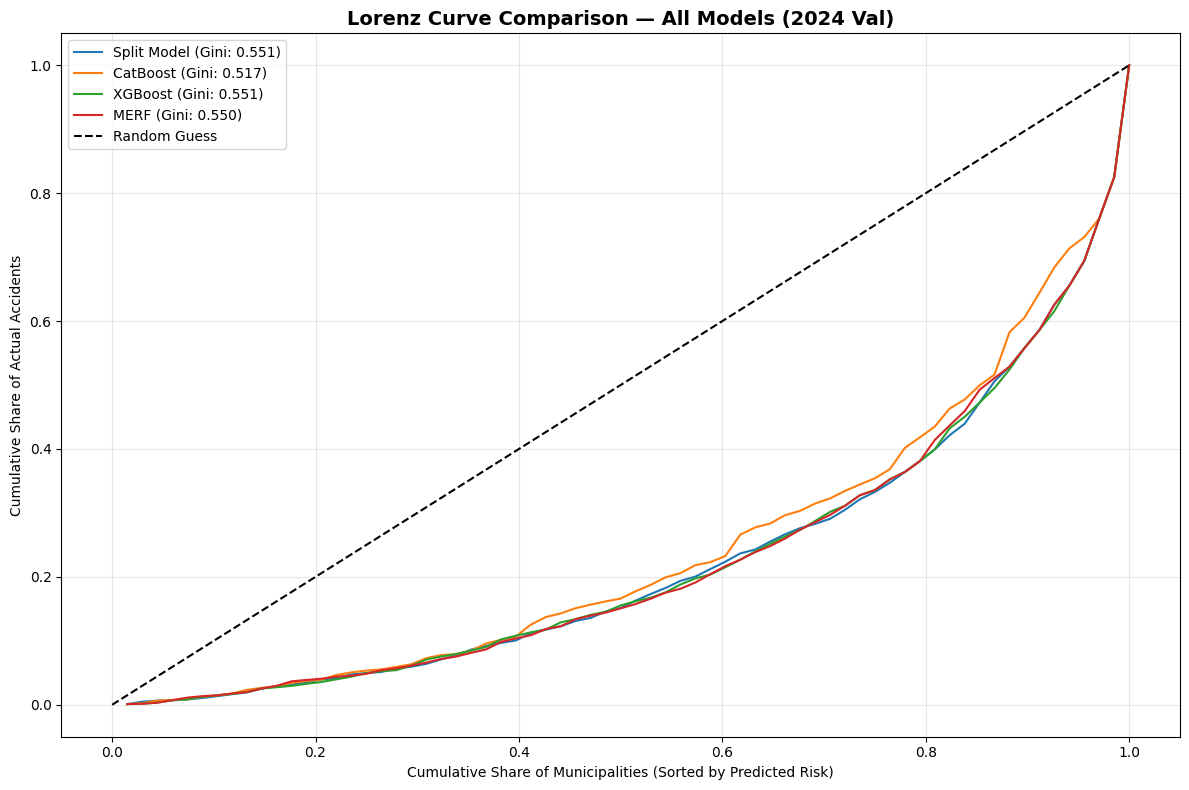

In [72]:
fig, ax = plt.subplots(figsize=(12, 8))

plot_lorenz_curve(y_val, val_preds_1, "Split Model", fig=fig, ax=ax)
plot_lorenz_curve(y_val, val_preds_cat, "CatBoost", fig=fig, ax=ax)
plot_lorenz_curve(y_val, val_preds_xgb, "XGBoost", fig=fig, ax=ax)
plot_lorenz_curve(y_val_merf, val_preds_merf, "MERF", fig=fig, ax=ax)

ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")
ax.set_title(
    "Lorenz Curve Comparison — All Models (2024 Val)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

In [73]:
models_eval = {
    "Two Stage Model": (y_val, val_preds_1),
    "CatBoost": (y_val, val_preds_cat),
    "XGBoost": (y_val, val_preds_xgb),
    "MERF": (y_val_merf, val_preds_merf),
}

In [74]:
gini_summary = []
for name, (yt_, yp_) in models_eval.items():
    yt_ = np.array(yt_).flatten()
    yp_ = np.array(yp_).flatten()
    df_g = pd.DataFrame({"true": yt_, "pred": yp_}).sort_values("pred")
    cum_true = np.cumsum(df_g["true"]) / (df_g["true"].sum() + 1e-9)
    cum_pop = np.arange(1, len(cum_true) + 1) / len(cum_true)
    gini = 1 - 2 * np.trapezoid(cum_true, cum_pop)
    mae = np.mean(np.abs(yt_ - yp_))
    gini_summary.append(
        {"Model": name, "Gini Coefficient": round(gini, 4), "MAE": round(mae, 4)}
    )

In [75]:
df_summary = pd.DataFrame(gini_summary).sort_values("Gini Coefficient", ascending=False)

In [76]:
print("\n===== MODEL COMPARISON SUMMARY (2024 Validation) =====")
print(df_summary.to_string(index=False))


===== MODEL COMPARISON SUMMARY (2024 Validation) =====
          Model  Gini Coefficient     MAE
        XGBoost            0.5507  7.2006
Two Stage Model            0.5506  8.1044
           MERF            0.5497  7.4105
       CatBoost            0.5172 22.8097


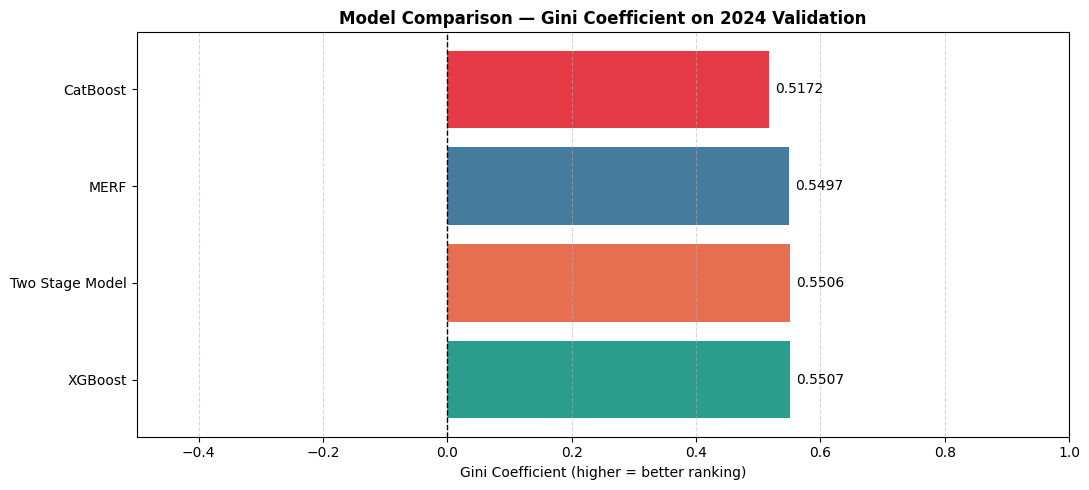

In [77]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = ["#2A9D8F", "#E76F51", "#457B9D", "#E63946", "#1D3557", "#9b59b6"]
bars = ax.barh(df_summary["Model"], df_summary["Gini Coefficient"], color=colors)
ax.axvline(x=0, color="black", linestyle="--", linewidth=1, label="Random Guess")

for bar, val in zip(bars, df_summary["Gini Coefficient"]):
    ax.text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=10,
    )

ax.set_xlabel("Gini Coefficient (higher = better ranking)")
ax.set_title("Model Comparison — Gini Coefficient on 2024 Validation", fontweight="bold")
ax.set_xlim(-0.5, 1.0)
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

fig.tight_layout()

In [78]:
df_mae = pd.DataFrame(gini_summary).sort_values("MAE")

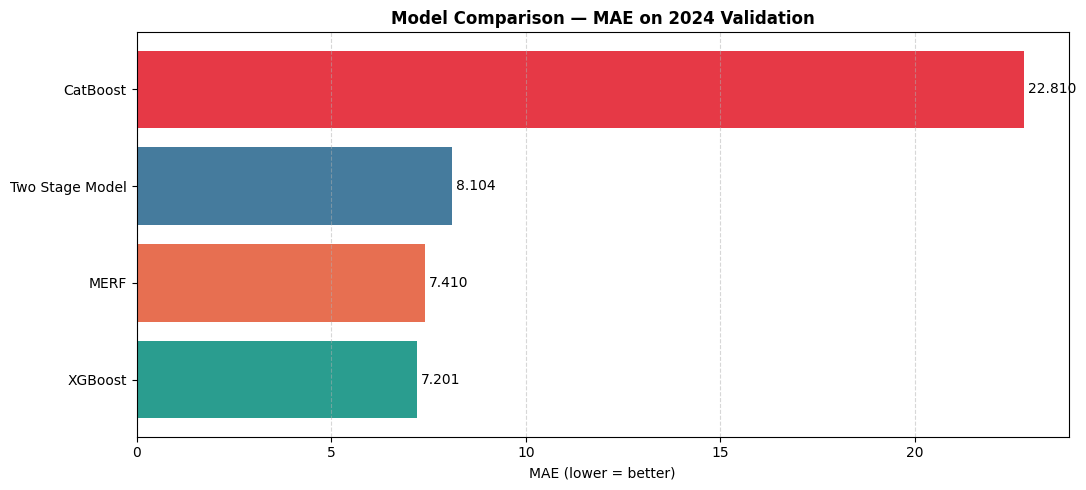

In [79]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#2A9D8F", "#E76F51", "#457B9D", "#E63946", "#1D3557", "#9b59b6"]
ax.barh(df_mae["Model"], df_mae["MAE"], color=colors)

for i, (_, row) in enumerate(df_mae.iterrows()):
    ax.text(
        row["MAE"] + 0.1, 
        i, 
        f'{row["MAE"]:.3f}', 
        va="center", 
        fontsize=10
    )

ax.set_xlabel("MAE (lower = better)")
ax.set_title("Model Comparison — MAE on 2024 Validation", fontweight="bold")
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

fig.tight_layout()

we're choosing **MERF** as our final model

In [85]:
final_results = test_df.with_columns(
    pl.Series(name="predicted_num_accidents", values=test_preds_merf.round().astype(int))
).with_columns([
    (pl.col("predicted_num_accidents") / pl.col("total_pop") * 1000).alias("pred_per_1k_residents"),
    pl.col("predicted_num_accidents").rank(descending=True).alias("risk_rank"),
]).sort("risk_rank")

In [86]:
print(final_results.sort("risk_rank"))

shape: (62, 60)
┌────────────┬────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ gemeente   ┆ year   ┆ is_weekend ┆ acc_durin ┆ … ┆ smoothed_ ┆ predicted ┆ pred_per_ ┆ risk_rank │
│ ---        ┆ ---    ┆ _ratio     ┆ g_is_week ┆   ┆ target    ┆ _num_acci ┆ 1k_reside ┆ ---       │
│ str        ┆ f64    ┆ ---        ┆ end       ┆   ┆ ---       ┆ dents     ┆ nts       ┆ f64       │
│            ┆        ┆ f64        ┆ ---       ┆   ┆ f64       ┆ ---       ┆ ---       ┆           │
│            ┆        ┆            ┆ f64       ┆   ┆           ┆ i64       ┆ f64       ┆           │
╞════════════╪════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Gent       ┆ 2025.0 ┆ 0.333333   ┆ 0.0       ┆ … ┆ 0.0       ┆ 568       ┆ 2.083203  ┆ 1.0       │
│ Brugge     ┆ 2025.0 ┆ 0.333333   ┆ 0.0       ┆ … ┆ 0.0       ┆ 219       ┆ 1.820706  ┆ 2.0       │
│ Leuven     ┆ 2025.0 ┆ 0.333333   ┆ 0.0       ┆ … ┆ 0.0       ┆ 207       

In [88]:
final_results[["gemeente", "predicted_num_accidents"]]

gemeente,predicted_num_accidents
str,i64
"""Gent""",568
"""Brugge""",219
"""Leuven""",207
"""Kortrijk""",133
"""Mechelen""",132
…,…
"""Sint-Pieters-Leeuw""",8
"""As""",7
"""Pepingen""",5


In [93]:
final_results = final_results.to_pandas()

In [98]:
final_results.to_csv("data/final_results.csv", index=False)

In [103]:
final_results.columns

Index(['gemeente', 'year', 'is_weekend_ratio', 'acc_during_is_weekend',
       'total_accidents', 'total_cycling_accidents', 'car_conflict',
       'severity', 'slick', 'light', 'intersection', 'school_peak',
       'local_accidents', 'total_hourly_flow', 'avg_temp', 'avg_precip',
       'avg_mun_wind', 'bad_weather_ratio', 'relative_sensor_age',
       'avg_income_per_capita', 'prof_earner_ratio', 'avg_employment_rate',
       'inbound_push_ratio', 'total_pop', 'pct_young_children',
       'pct_school_kids', 'pct_uni_students', 'pct_young_profs',
       'pct_senior_profs', 'pct_seniors', 'pct_male', 'pct_female',
       'pct_belgian', 'pct_foreign', 'pct_single', 'pct_married',
       'pct_widowed', 'pct_divorced', 'accident_rate_per_flow',
       'accident_rate_per_capita', 'severity_index', 'prev_year_severe_count',
       'prev_year_dark_count', 'prev_year_weekend_count',
       'prev_year_local_accidents', 'prev_year_school_accidents',
       'prev_year_slick_accidents', 'prev_yea

In [106]:
final_results["intersection"].sum()

np.float64(0.0)

In [115]:
df_research_master.filter(pl.col("year") == 2025)["light"].sum()

0

In [117]:
# The simplest and most idiomatic way
df_research_master.filter(pl.col("year") == 2025)["gemeente"].n_unique()

62